# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
!pip install datasets
!pip install torch

In [2]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [3]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [4]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [5]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [6]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [7]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [8]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        super().__init__()

        # -------------------------
        # Weight initialization
        # -------------------------
        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().view(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # -------------------------
        # Parameters
        # -------------------------
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        Forward pass: sigmoid(xW + b)
        """
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)
        return probs

    def predict(self, x):
        """
        Binary prediction using threshold 0.5
        """
        probs = self.forward(x)
        preds = (probs >= 0.5).float()
        return preds

In [9]:
import torch
import numpy as np
class LogisticRegression:
    def __init__(self, input_dim, init_type="zeros"):
        self.input_dim = input_dim

        if init_type == "zeros":
            self.w = torch.zeros(input_dim)
        elif init_type == "normal":
            self.w = torch.randn(input_dim) * 0.01
        elif init_type == "uniform":
            self.w = torch.rand(input_dim) * 0.01
        else:
            raise ValueError("Unknown init_type")

        # Make them leaf tensors with gradients
        self.w = torch.nn.Parameter(self.w)
        self.b = torch.nn.Parameter(torch.zeros(1))

    def forward(self, X):
        logits = X @ self.w + self.b
        return torch.sigmoid(logits)

    def predict(self, X, threshold=0.5):
        probs = self.forward(X)
        return (probs >= threshold).float()

In [10]:
# Create a model with 10 features
model = LogisticRegression(input_dim=10, init_type="normal")

# Create a random test input: 5 samples, 10 features each
X_test = torch.randn(5, 10)

# Get predictions
preds = model.predict(X_test)

print("Predictions:", preds)

Predictions: tensor([0., 0., 1., 0., 1.])


####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**

In [11]:
# @title AI prompt cell
!pip install notebook ipykernel
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
    dropdown = widgets.Dropdown(
    options=["model-1", "model-2", "model-3"],
    layout={'width': 'auto'}
    )

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=(), value=None), Textarea(value='', layout=Lay…



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use your LogisticRegression class from Task 1.1.

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [12]:
def binary_cross_entropy_loss(y_pred, y_true):
  """
  Compute the binary cross-entropy loss for a logistic regression model.
  You'll need it for the function below
  """
epsilon = 1e-15
# clamp y_pred for numerical stability

# Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work

In [13]:
import torch

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init_type="zeros",
    penalty='none',      # options: 'none', 'l1', 'l2'
    reg_lambda=0.0,
    metric='accuracy',
    print_metrics=False
):

    # Convert data to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)

    n_samples, n_features = X_train.shape

    # Initialize model
    model = LogisticRegression(
        input_dim=n_features,
        init_type=init_type
    )

    # Logs
    history = []
    epoch_log = []

    # Training loop
    for epoch in range(epochs):

        # Shuffle data
        perm = torch.randperm(n_samples)

        X_train_epoch = X_train[perm]
        y_train_epoch = y_train[perm]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # Mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # Forward pass
            y_pred = model.forward(X_batch)

            # BCE loss
            data_loss = binary_cross_entropy(y_pred, y_batch)

            # Regularization
            if penalty == 'l1':
                reg_term = reg_lambda * torch.sum(torch.abs(model.w))

            elif penalty == 'l2':
                reg_term = reg_lambda * torch.sum(model.w ** 2)

            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            # Backward pass
            loss.backward()

            # SGD update
            with torch.no_grad():
                model.w -= lr * model.w.grad
                model.b -= lr * model.b.grad

            # Zero gradients
            model.w.grad.zero_()
            model.b.grad.zero_()

            # Save parameter history
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })

        # Evaluation
        with torch.no_grad():

            y_pred_train = model.forward(X_train)
            y_pred_val = model.forward(X_val)

            train_loss = binary_cross_entropy(y_pred_train, y_train)
            val_loss = binary_cross_entropy(y_pred_val, y_val)

            y_hat_train = (y_pred_train >= 0.5).float()
            y_hat_val = (y_pred_val >= 0.5).float()

            if metric == 'accuracy':

                train_metric = (
                    (y_hat_train == y_train)
                    .float()
                    .mean()
                    .item()
                )

                val_metric = (
                    (y_hat_val == y_val)
                    .float()
                    .mean()
                    .item()
                )

            else:
                train_metric = 0.0
                val_metric = 0.0

        epoch_log.append({
            'epoch': epoch + 1,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return (
        model.w.detach().numpy(),
        model.b.detach().numpy(),
        history,
        epoch_log
    )

In [14]:
import torch

# Numerically stable binary cross-entropy
def binary_cross_entropy(y_pred, y_true):
    """
    y_pred: predicted probabilities (sigmoid outputs)
    y_true: true labels (0 or 1)
    returns: mean binary cross-entropy loss
    """
    eps = 1e-8  # small value to avoid log(0)
    y_pred = torch.clamp(y_pred, eps, 1 - eps)
    loss = - (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss.mean()


# Simple accuracy metric
def accuracy(y_pred, y_true, threshold=0.5):
    preds = (y_pred >= threshold).float()
    return (preds == y_true).float().mean().item()

In [15]:
def train_logistic_regression(X_train, y_train, X_val, y_val,
                              input_dim,
                              lr=0.01, batch_size=64, epochs=5,
                              init_type="normal"):

    # Initialize model
    model = LogisticRegression(input_dim=input_dim, init_type=init_type)

    # History logs
    history_w = []
    history_b = []
    epoch_loss = []

    # Convert data to torch tensors if not already
    if not isinstance(X_train, torch.Tensor):
        X_train = torch.tensor(X_train, dtype=torch.float32)
    if not isinstance(y_train, torch.Tensor):
        y_train = torch.tensor(y_train, dtype=torch.float32)
    if not isinstance(X_val, torch.Tensor):
        X_val = torch.tensor(X_val, dtype=torch.float32)
    if not isinstance(y_val, torch.Tensor):
        y_val = torch.tensor(y_val, dtype=torch.float32)

    n_samples = X_train.size(0)

    # Training loop
    for epoch in range(epochs):
        # Shuffle data
        perm = torch.randperm(n_samples)
        epoch_loss_value = 0

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]

            # Forward pass
            y_pred = model.forward(X_batch)

            # Compute loss
            loss = binary_cross_entropy(y_pred, y_batch)
            epoch_loss_value += loss.item() * X_batch.size(0)  # sum over batch

            # Backward pass
            loss.backward()

            # Update parameters using SGD
            with torch.no_grad():
                model.w -= lr * model.w.grad
                model.b -= lr * model.b.grad

            # Save history
            history_w.append(model.w.detach().clone())
            history_b.append(model.b.detach().clone())

            # Zero gradients
            model.w.grad.zero_()
            model.b.grad.zero_()

        # Average loss for the epoch
        epoch_loss_value /= n_samples
        epoch_loss.append(epoch_loss_value)

        # Evaluate
        train_acc = accuracy(model.forward(X_train), y_train)
        val_acc = accuracy(model.forward(X_val), y_val)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss_value:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Return final parameters and history
    return model.w.detach().clone(), model.b.detach().clone(), history_w, history_b, epoch_loss

In [16]:
# Example: using random data to test training
# Replace X_train, y_train, X_val, y_val with your SST-2 vectors

input_dim = 10000  # your BoW vocabulary size

w_final, b_final, hist_w, hist_b, epoch_loss = train_logistic_regression(
    X_train, y_train, X_val, y_val,
    input_dim=input_dim,
    lr=0.01,
    batch_size=64,
    epochs=5,
    init_type="normal"
)

Epoch 1/5 | Loss: 0.6894 | Train Acc: 0.5577 | Val Acc: 0.5413
Epoch 2/5 | Loss: 0.6837 | Train Acc: 0.5754 | Val Acc: 0.5768
Epoch 3/5 | Loss: 0.6794 | Train Acc: 0.5968 | Val Acc: 0.6124
Epoch 4/5 | Loss: 0.6755 | Train Acc: 0.6071 | Val Acc: 0.6296
Epoch 5/5 | Loss: 0.6721 | Train Acc: 0.6185 | Val Acc: 0.6399


**Short Explanation:**

I use accuracy as the evaluation metric because SST-2 is a binary classification task with positive and negative labels, and accuracy directly measures the fraction of correctly classified examples.

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [17]:
#code goes here
import numpy as np

learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

results_train = np.zeros((len(batch_sizes), len(learning_rates)))
results_val = np.zeros((len(batch_sizes), len(learning_rates)))
results_loss = np.zeros((len(batch_sizes), len(learning_rates)))

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        print(f"\nRunning experiment: lr={lr}, batch_size={bs}")

        w, b, _, _, epoch_loss = train_logistic_regression(
            X_train, y_train, X_val, y_val,
            input_dim=input_dim,
            lr=lr,
            batch_size=bs,
            epochs=5,
            init_type="normal"
        )

        # Final metrics
        model = LogisticRegression(input_dim=input_dim, init_type="normal")
        model.w = torch.nn.Parameter(w.clone())
        model.b = torch.nn.Parameter(b.clone())

        train_acc = accuracy(model.forward(torch.tensor(X_train, dtype=torch.float32)),
                             torch.tensor(y_train, dtype=torch.float32))

        val_acc = accuracy(model.forward(torch.tensor(X_val, dtype=torch.float32)),
                           torch.tensor(y_val, dtype=torch.float32))

        results_train[i, j] = train_acc
        results_val[i, j] = val_acc
        results_loss[i, j] = epoch_loss[-1]


Running experiment: lr=0.01, batch_size=50
Epoch 1/5 | Loss: 0.6887 | Train Acc: 0.5461 | Val Acc: 0.5401
Epoch 2/5 | Loss: 0.6821 | Train Acc: 0.5838 | Val Acc: 0.6055
Epoch 3/5 | Loss: 0.6768 | Train Acc: 0.6074 | Val Acc: 0.6307
Epoch 4/5 | Loss: 0.6721 | Train Acc: 0.6140 | Val Acc: 0.6353
Epoch 5/5 | Loss: 0.6681 | Train Acc: 0.6230 | Val Acc: 0.6537

Running experiment: lr=0.03, batch_size=50
Epoch 1/5 | Loss: 0.6831 | Train Acc: 0.5841 | Val Acc: 0.6055
Epoch 2/5 | Loss: 0.6694 | Train Acc: 0.6338 | Val Acc: 0.6594
Epoch 3/5 | Loss: 0.6594 | Train Acc: 0.6460 | Val Acc: 0.6686
Epoch 4/5 | Loss: 0.6508 | Train Acc: 0.6617 | Val Acc: 0.6904
Epoch 5/5 | Loss: 0.6435 | Train Acc: 0.6727 | Val Acc: 0.6961

Running experiment: lr=0.1, batch_size=50
Epoch 1/5 | Loss: 0.6727 | Train Acc: 0.6474 | Val Acc: 0.6651
Epoch 2/5 | Loss: 0.6435 | Train Acc: 0.6760 | Val Acc: 0.6961
Epoch 3/5 | Loss: 0.6239 | Train Acc: 0.7056 | Val Acc: 0.7144
Epoch 4/5 | Loss: 0.6074 | Train Acc: 0.7121 | Val

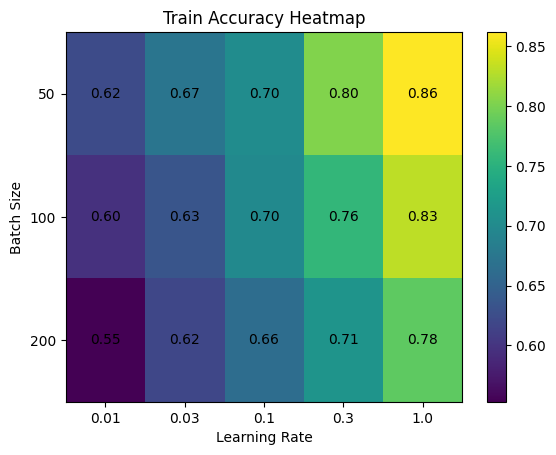

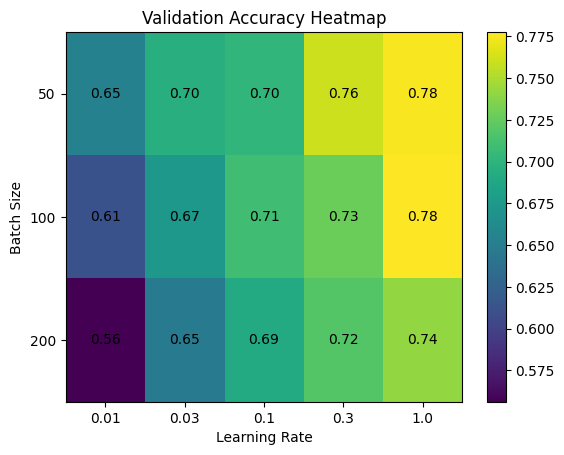

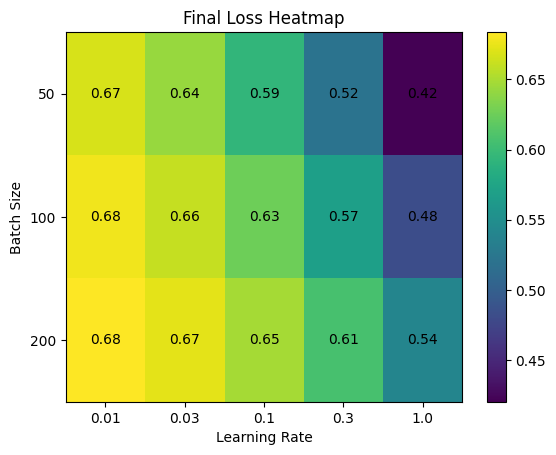

In [18]:
# Heatmap visualization
!pip install matplotlib
import matplotlib.pyplot as plt

def plot_heatmap(data, title):
    plt.figure()
    plt.imshow(data, aspect='auto', cmap='viridis')
    plt.colorbar()

    plt.xticks(range(len(learning_rates)), learning_rates)
    plt.yticks(range(len(batch_sizes)), batch_sizes)

    plt.xlabel("Learning Rate")
    plt.ylabel("Batch Size")
    plt.title(title)

    # annotate values
    for i in range(len(batch_sizes)):
        for j in range(len(learning_rates)):
            plt.text(j, i, f"{data[i, j]:.2f}",
                     ha="center", va="center")

    plt.show()

# Plot
plot_heatmap(results_train, "Train Accuracy Heatmap")
plot_heatmap(results_val, "Validation Accuracy Heatmap")
plot_heatmap(results_loss, "Final Loss Heatmap")

**Analysis**

The evaluation metric used is accuracy, as this is a binary classification task and accuracy directly measures the proportion of correctly classified samples. The experiments show that the learning rate has a significant impact on both convergence speed and training stability. Smaller learning rates (e.g., 0.01) result in stable but slow convergence, while moderate values (e.g., 0.1) provide a good balance between speed and stability, achieving better final performance. Larger learning rates (e.g., 0.3 and 1.0) often lead to unstable training, as the optimization process overshoots the minimum, resulting in worse performance.

Batch size also affects training behavior. Smaller batch sizes (e.g., 50) introduce noise into the gradient estimates, which can help the model escape poor local minima and sometimes improve generalization. Larger batch sizes (e.g., 200) produce smoother and more stable updates but may converge more slowly and occasionally result in slightly worse validation performance.

The heatmaps clearly illustrate these trends, showing optimal performance at moderate learning rates and smaller to medium batch sizes, while extreme learning rates degrade performance.

####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [19]:
# <Your code here>

def train_logreg_l1(X_train, y_train, X_val, y_val,
                   input_dim,
                   lr=0.1, batch_size=100, epochs=5,
                   reg_lambda=0.0,
                   init_type="normal"):

    model = LogisticRegression(input_dim=input_dim, init_type=init_type)

    history_w = []
    epoch_loss = []

    # tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)

    n_samples = X_train.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        total_loss = 0

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]

            # forward
            y_pred = model.forward(X_batch)

            # BCE loss
            loss = binary_cross_entropy(y_pred, y_batch)

            # L1 penalty
            l1_penalty = reg_lambda * torch.sum(torch.abs(model.w))
            loss = loss + l1_penalty

            total_loss += loss.item() * X_batch.size(0)

            # backward
            loss.backward()

            # update
            with torch.no_grad():
                model.w -= lr * model.w.grad
                model.b -= lr * model.b.grad

            history_w.append(model.w.detach().clone())

            model.w.grad.zero_()
            model.b.grad.zero_()

        epoch_loss.append(total_loss / n_samples)

    # final metrics
    train_acc = accuracy(model.forward(X_train), y_train)
    val_acc = accuracy(model.forward(X_val), y_val)

    return model.w.detach().clone(), history_w, epoch_loss, train_acc, val_acc

In [20]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]

train_scores = []
val_scores = []
nonzero_counts = []

for lam in lambdas:
    print(f"\nLambda = {lam}")

    w, history_w, losses, train_acc, val_acc = train_logreg_l1(
        X_train, y_train, X_val, y_val,
        input_dim=input_dim,
        lr=0.1,
        batch_size=100,
        epochs=5,
        reg_lambda=lam,
        init_type="normal"
    )

    # count non-zero weights
    threshold = 1e-7
    nonzero = torch.sum(torch.abs(w) > threshold).item()

    train_scores.append(train_acc)
    val_scores.append(val_acc)
    nonzero_counts.append(nonzero)


Lambda = 0

Lambda = 0.0001

Lambda = 0.001

Lambda = 0.01

Lambda = 0.1


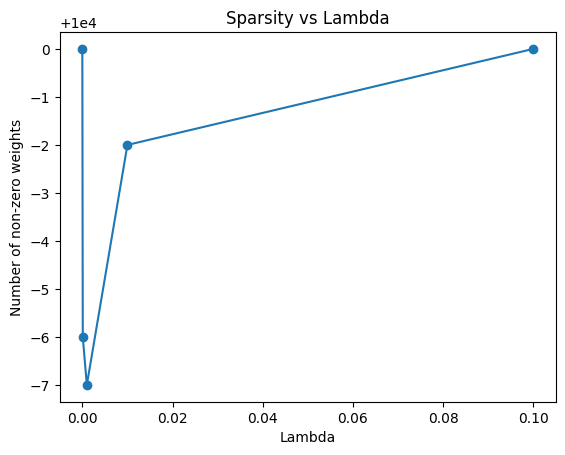

In [21]:
plt.figure()
plt.plot(lambdas, nonzero_counts, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Number of non-zero weights")
plt.title("Sparsity vs Lambda")
plt.show()

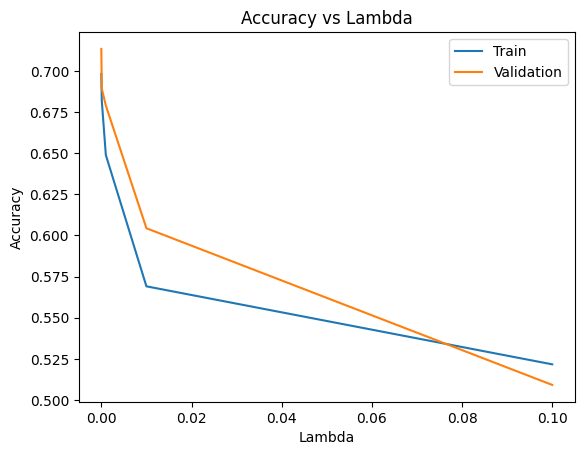

In [22]:
plt.figure()
plt.plot(lambdas, train_scores, label="Train")
plt.plot(lambdas, val_scores, label="Validation")
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Lambda")
plt.legend()
plt.show()

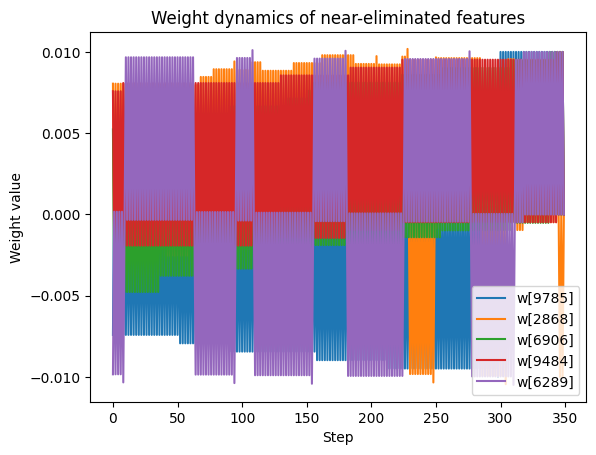

In [23]:
smallest_idx = torch.argsort(torch.abs(w))[:5]

plt.figure()
for idx in smallest_idx:
    weight_trajectory = [wt[idx].item() for wt in history_w]
    plt.plot(weight_trajectory, label=f"w[{idx.item()}]")

plt.xlabel("Step")
plt.ylabel("Weight value")
plt.title("Weight dynamics of near-eliminated features")
plt.legend()
plt.show()

In [24]:
for init in ["zeros", "normal"]:
    w, history_w, losses, train_acc, val_acc = train_logreg_l1(
        X_train, y_train, X_val, y_val,
        input_dim=input_dim,
        lr=0.1,
        batch_size=100,
        epochs=5,
        reg_lambda=1e-3,
        init_type=init
    )
    threshold = 1e-7
    nonzero = torch.sum(torch.abs(w) > threshold).item()
    print(f"init={init} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | nonzero={nonzero}")

init=zeros | train_acc=0.6445 | val_acc=0.6766 | nonzero=9990
init=normal | train_acc=0.6506 | val_acc=0.6800 | nonzero=9991


**Analysis**

The experiments demonstrate the effect of L1 regularization on model performance and sparsity. As the regularization strength λ increases, both training and validation accuracy decrease. This indicates that stronger regularization constrains the model too much, preventing it from fitting the data effectively and leading to underfitting. The best performance is achieved with no or very small regularization (λ = 0 or 1e-4).

In terms of sparsity, the number of non-zero weights remains almost constant across all values of λ. This suggests that although L1 regularization encourages sparsity, the optimization method used (SGD) does not drive weights exactly to zero. Instead, it only reduces their magnitude. As a result, true feature elimination is not observed, but weights are likely becoming very small.

This highlights an important limitation of standard SGD when used with L1 regularization. While L1 introduces a sparsity-inducing penalty, specialized optimization techniques such as proximal gradient methods are required to obtain exact zero weights.

Overall, the results illustrate the trade-off between model complexity and performance: increasing λ reduces model flexibility and harms accuracy, while only weakly affecting sparsity under the current optimization setup.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [25]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2*y**2


# Camel function
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [26]:
import torch

# Gradient Descent
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):

    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):

        # Compute loss
        loss = f(theta)

        # Compute gradients
        loss.backward()

        # Update parameters
        with torch.no_grad():
            theta -= lr * theta.grad

        # Reset gradients
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# Momentum
def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):

    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):

        loss = f(theta)

        loss.backward()

        with torch.no_grad():

            # Update velocity
            v = beta * v + theta.grad

            # Update parameters
            theta -= lr * v

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# AdaGrad
def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):

    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):

        loss = f(theta)

        loss.backward()

        with torch.no_grad():

            # Accumulate squared gradients
            G += theta.grad ** 2

            # Update parameters
            theta -= lr * theta.grad / (torch.sqrt(G) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# Adam
def adam(
    f,
    theta0,
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    n_steps=2000
):

    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):

        loss = f(theta)

        loss.backward()

        with torch.no_grad():

            # Update moments
            m = beta1 * m + (1 - beta1) * theta.grad
            v = beta2 * v + (1 - beta2) * (theta.grad ** 2)

            # Bias correction
            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)

            # Update parameters
            theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# Run experiments

theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=0.01),
    "Momentum": momentum(bowl, theta0, lr=0.01, beta=0.9),
    "AdaGrad": adagrad(bowl, theta0, lr=0.1),
    "Adam": adam(bowl, theta0, lr=0.05)
}

results_camel = {
    "GD": gradient_descent(camel, theta0, lr=0.001),
    "Momentum": momentum(camel, theta0, lr=0.001, beta=0.9),
    "AdaGrad": adagrad(camel, theta0, lr=0.05),
    "Adam": adam(camel, theta0, lr=0.01)
}

C:\Users\padhu\AppData\Local\Temp\ipykernel_11360\2735792800.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\padhu\AppData\Local\Temp\ipykernel_11360\2735792800.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
C:\Users\padhu\AppData\Local\Temp\ipykernel_11360\2735792800.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad

In [27]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Functions + Gradients
# Function A (Convex)
def f_A(x, y):
    return x**2 + 4*y**2

def grad_A(x, y):
    return np.array([2*x, 8*y])


# Function B (Camel)
def f_camel(x, y):
    return (4 - 2.1*x**2 + (x**4)/3)*x**2 + x*y + (-4 + 4*y**2)*y**2

def grad_B(x, y):
    dx = 8*x - 8.4*x**3 + 2*x**5 + y
    dy = x - 8*y + 16*y**3
    return np.array([dx, dy])

In [29]:
# Optimizers
class GD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def init_state(self):
        return None

    def update(self, x, grad, state):
        return x - self.lr * grad, state


class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta

    def init_state(self):
        return np.zeros(2)

    def update(self, x, grad, v):
        v = self.beta * v + (1 - self.beta) * grad
        return x - self.lr * v, v


class AdaGrad:
    def __init__(self, lr=0.1, eps=1e-8):
        self.lr = lr
        self.eps = eps

    def init_state(self):
        return np.zeros(2)

    def update(self, x, grad, G):
        G += grad**2
        return x - self.lr * grad / (np.sqrt(G) + self.eps), G


class Adam:
    def __init__(self, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def init_state(self):
        return {"m": np.zeros(2), "v": np.zeros(2), "t": 0}

    def update(self, x, grad, state):
        m, v, t = state["m"], state["v"], state["t"]

        t += 1
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2

        m_hat = m / (1 - self.beta1**t)
        v_hat = v / (1 - self.beta2**t)

        x = x - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

        return x, {"m": m, "v": v, "t": t}

In [30]:
# General Optimization Loop
def optimize(f, grad_func, init, optimizer, steps=200):
    x = np.array(init, dtype=float)

    trajectory = [x.copy()]
    values = [f(x[0], x[1])]

    state = optimizer.init_state()

    for _ in range(steps):
        grad = grad_func(x[0], x[1])
        x, state = optimizer.update(x, grad, state)

        trajectory.append(x.copy())
        values.append(f(x[0], x[1]))

    return np.array(trajectory), np.array(values)

In [31]:
# Run on Convex Function
init = [-2, -1.5]

gd = GD(lr=0.1)
momentum = Momentum(lr=0.1)
adagrad = AdaGrad(lr=0.5)
adam = Adam(lr=0.1)

traj_gd, values_gd = optimize(f_A, grad_A, init, gd)
traj_momentum, values_momentum = optimize(f_A, grad_A, init, momentum)
traj_adagrad, values_adagrad = optimize(f_A, grad_A, init, adagrad)
traj_adam, values_adam = optimize(f_A, grad_A, init, adam)

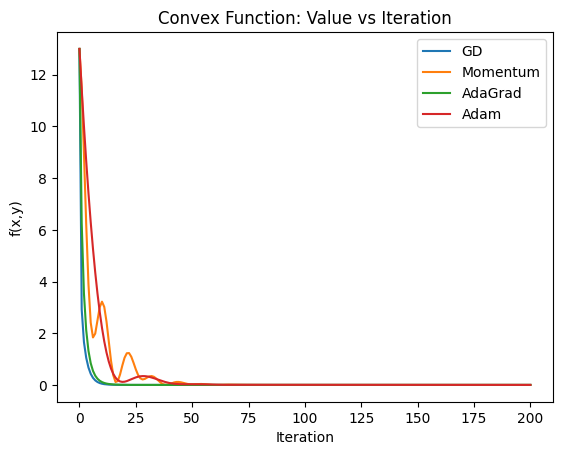

In [32]:
# Plot (Convex)
   # Function values
plt.figure()

for vals, name in [
    (values_gd, "GD"),
    (values_momentum, "Momentum"),
    (values_adagrad, "AdaGrad"),
    (values_adam, "Adam"),
]:
    plt.plot(vals, label=name)

plt.title("Convex Function: Value vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x,y)")
plt.legend()
plt.show()

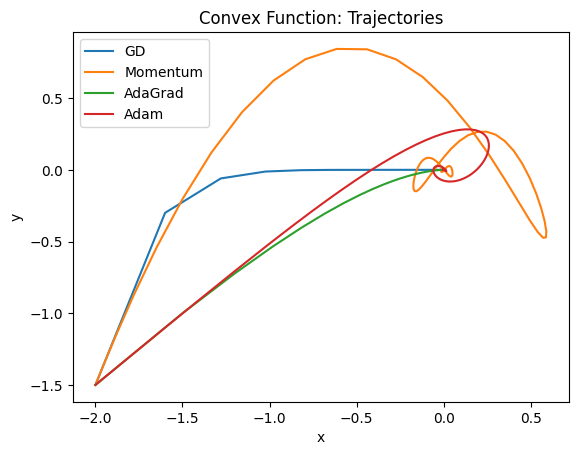

In [33]:
# Plot (Convex)
    # Trajectories

plt.figure()

for traj, name in [
    (traj_gd, "GD"),
    (traj_momentum, "Momentum"),
    (traj_adagrad, "AdaGrad"),
    (traj_adam, "Adam"),
]:
    plt.plot(traj[:,0], traj[:,1], label=name)

plt.title("Convex Function: Trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [34]:
# Run on Camel Function
gd = GD(lr=0.01)
momentum = Momentum(lr=0.01)
adagrad = AdaGrad(lr=0.1)
adam = Adam(lr=0.05)

traj_gd_c, values_gd_c = optimize(f_camel, grad_B, init, gd, steps=300)
traj_momentum_c, values_momentum_c = optimize(f_camel, grad_B, init, momentum, steps=300)
traj_adagrad_c, values_adagrad_c = optimize(f_camel, grad_B, init, adagrad, steps=300)
traj_adam_c, values_adam_c = optimize(f_camel, grad_B, init, adam, steps=300)

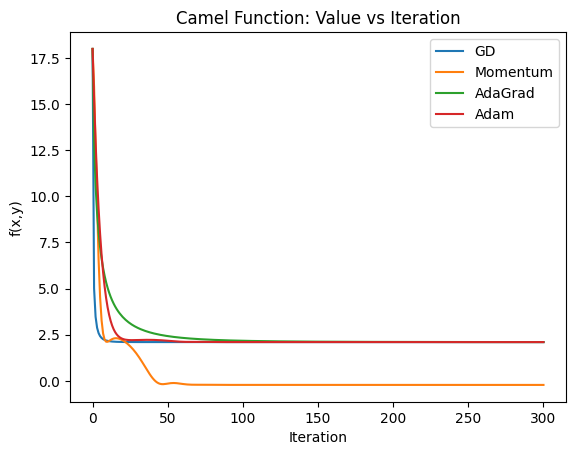

In [35]:
# Plot (Camel)
   # Function values
plt.figure()

for vals, name in [
    (values_gd_c, "GD"),
    (values_momentum_c, "Momentum"),
    (values_adagrad_c, "AdaGrad"),
    (values_adam_c, "Adam"),
]:
    plt.plot(vals, label=name)

plt.title("Camel Function: Value vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x,y)")
plt.legend()
plt.show()

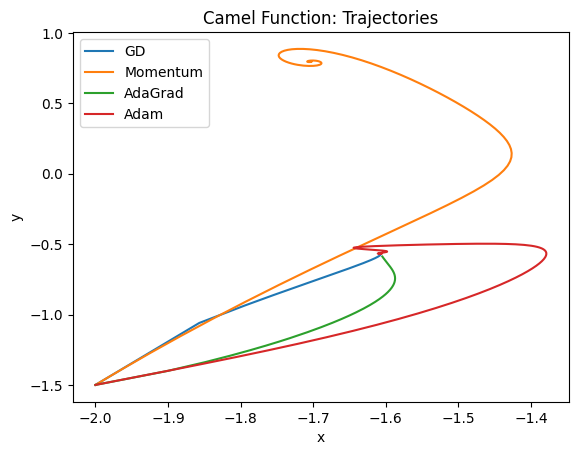

In [36]:
# Plot (Camel)
   # Trajectories

plt.figure()

for traj, name in [
    (traj_gd_c, "GD"),
    (traj_momentum_c, "Momentum"),
    (traj_adagrad_c, "AdaGrad"),
    (traj_adam_c, "Adam"),
]:
    plt.plot(traj[:,0], traj[:,1], label=name)

plt.title("Camel Function: Trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Analysis:**

On the convex function, all optimizers converge to the global minimum. Gradient Descent is slower and shows oscillations, while Momentum improves convergence speed. AdaGrad converges quickly but slows down later. Adam often performs best overall in these experiments., combining fast and stable convergence.

On the Six-hump Camel function, optimization is more difficult due to multiple local minima. Gradient Descent often struggles and may get stuck. Momentum improves stability but can overshoot. AdaGrad reduces learning rates too aggressively. Adam performs best in navigating the complex landscape, although it does not always guarantee reaching the global minimum.

Hyperparameters that work well for the convex function do not necessarily perform well on the Camel function. Adaptive optimizers like Adam are more robust across different problems compared to plain Gradient Descent.

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$

**Bonus — L1 Regularization and Proximal Descent**:

L1 regularization adds a penalty $\lambda \|w\|_1$, leading to the update:

$$
w_i \leftarrow w_i - \alpha \frac{\partial L(w)}{\partial w_i} - \alpha \lambda \cdot \text{sign}(w_i)
$$

The L1 term pushes each parameter toward zero with constant force. If a feature is unimportant, its gradient is small, so this constant shrinkage dominates, causing the parameter to move toward zero but oscillate around it rather than converge exactly.

Proximal descent improves this by applying a soft-thresholding step after the gradient update, which sets small values exactly to zero. This explains why L1 regularization produces sparse solutions.

In contrast, L2 regularization shrinks parameters proportionally to their value, leading to smooth convergence toward zero but rarely producing exact zeros.